In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib
matplotlib.rcParams.update({'font.size': 10, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern'], 'figure.figsize': (10,10)})


from koala import plotting as pl
from koala import graph_utils as gu
from koala.pointsets import uniform
from koala.graph_color import edge_color
from koala.voronization import generate_lattice

from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes

In [2]:
points = uniform(20)
lattice = generate_lattice(points)
lattice = gu.lloyd_relaxation(lattice, 10)

ujk = np.ones(lattice.n_edges)
fluxes = fluxes_from_ujk(lattice, ujk,real = False)

coloring = edge_color(lattice)
coloring = coloring[1]




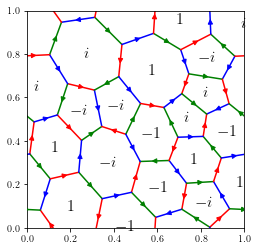

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_aspect("equal")
pl.plot_edges(lattice, ax=ax, labels = coloring, color_scheme=['r','g','b'], directions=ujk)

def make_imag_string(x):
    if x.real == 0:
        pm = ''if int(x.imag) == 1 else '-'
        return f'${pm}i$'
    else:
        return f'${int(x.real)}$' 
f = [make_imag_string(x) for x in fluxes]
centers = [p.center for p in lattice.plaquettes]
for pos, text in zip(centers, f):
    plt.text(pos[0]%1, pos[1]%1 , text, horizontalalignment='center', verticalalignment='center', fontsize=16 )

plt.savefig("amorphous_colouring.pdf")

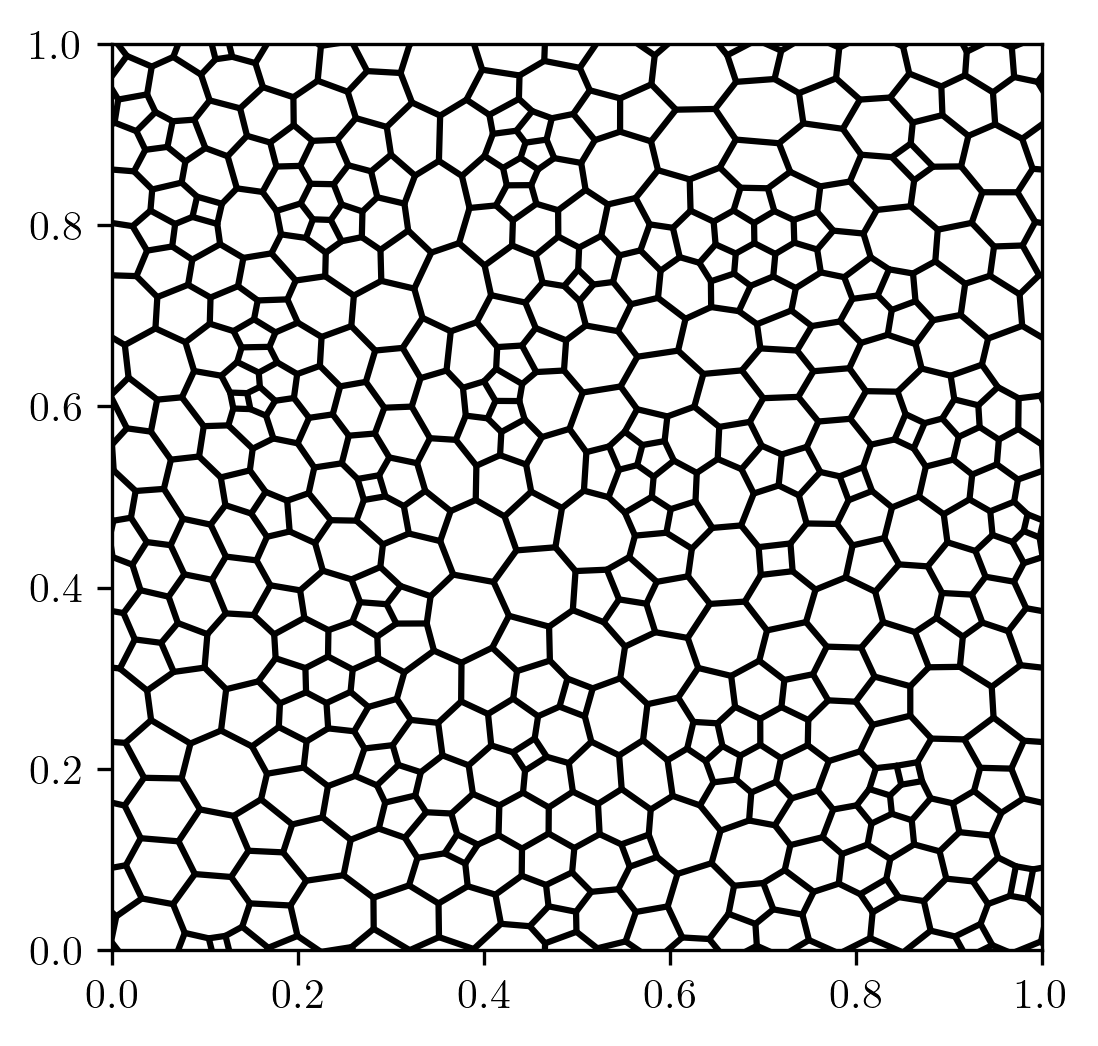

In [11]:
points = uniform(400)
lattice = generate_lattice(points)
lattice = gu.lloyd_relaxation(lattice, 10)

fig, ax = plt.subplots(figsize=(4, 4), dpi = 300)
pl.plot_edges(lattice)
plt.savefig("amorphous_lat.pdf")